# **Paricial Galaxy Zoo // Isabel Nieto y Leonardo Tovar**


### Importación

In [19]:
import os
import random
import math
import numpy as np
import pandas as pd
import seaborn as sns
import time
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize, LabelEncoder, StandardScaler
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt
from scipy.stats import loguniform 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import randint
from collections import Counter

# Carga de dataset

In [20]:
def cargar_datos(
    carpeta="images_training_rev1",
    archivo_clasificaciones="training_solutions_rev1.csv",
    max_imagenes=61578,
    size=(128, 128)
):
    # 1. Leer archivo CSV con clasificaciones
    df = pd.read_csv(archivo_clasificaciones)
    print(f"Archivo CSV cargado con {len(df)} filas.")

    # Verificar columna identificadora
    if "GalaxyID" not in df.columns:
        raise ValueError("El archivo CSV debe tener una columna 'GalaxyID' que identifique las imágenes.")

    # Crear lista de IDs disponibles
    galaxy_ids = df["GalaxyID"].astype(str).tolist()

    # 2. Listar imágenes disponibles
    archivos = [f for f in os.listdir(carpeta) if f.lower().endswith((".jpg", ".png", ".jpeg"))]

    # Filtrar solo imágenes cuyo GalaxyID exista en el CSV
    archivos_validos = [f for f in archivos if f.split(".")[0] in galaxy_ids]

    # Tomar muestra aleatoria
    if len(archivos_validos) > max_imagenes:
        archivos_validos = random.sample(archivos_validos, max_imagenes)

    print(f"Se seleccionaron {len(archivos_validos)} imágenes aleatorias.")

    # 3. Cargar imágenes y asociarlas con su etiqueta
    X, y = [], []

    for nombre in archivos_validos:
        galaxy_id = nombre.split(".")[0]
        fila = df[df["GalaxyID"] == int(galaxy_id)].iloc[0]
        etiqueta = fila.drop("GalaxyID").idxmax()  # clasificación más probable

        ruta = os.path.join(carpeta, nombre)
        try:
            img = Image.open(ruta).convert("RGB").resize(size)
            X.append(np.array(img))
            y.append(etiqueta)
        except Exception as e:
            print(f"Error al cargar {nombre}: {e}")

    X = np.array(X)
    print(f"Se cargaron {len(X)} imágenes etiquetadas de '{carpeta}'.")
    return X, y


# Ejemplo de uso
if __name__ == "__main__":
    X, y = cargar_datos(
        carpeta="images_training_rev1",
        archivo_clasificaciones="training_solutions_rev1.csv",
        max_imagenes=61578,
        size=(128, 128)
    )

Archivo CSV cargado con 61578 filas.
Se seleccionaron 61578 imágenes aleatorias.
Se cargaron 61578 imágenes etiquetadas de 'images_training_rev1'.


# Exploración inicial del dataset

Número de filas donde Class1.3 es argmax: 13

Estadísticas de la columna Class1.3 en esas filas:
count    13.000000
mean      0.701788
std       0.117450
min       0.516376
25%       0.618000
50%       0.680000
75%       0.778000
max       0.935147
Name: Class1.3, dtype: float64
Prob > 0.5: 13
Prob > 0.33: 13
Prob > 0.2: 13
Prob > 0.1: 13

Estadísticas de la probabilidad máxima en esas filas:
count    13.000000
mean      0.701788
std       0.117450
min       0.516376
25%       0.618000
50%       0.680000
75%       0.778000
max       0.935147
dtype: float64

Fila 0 (index 1791) - Class1.3=0.778 - top3: {'Class1.3': 0.778, 'Class6.2': 0.7, 'Class6.1': 0.3}

Fila 1 (index 16618) - Class1.3=0.876 - top3: {'Class1.3': 0.876458, 'Class6.2': 0.544695, 'Class6.1': 0.455305}

Fila 2 (index 17392) - Class1.3=0.935 - top3: {'Class1.3': 0.935147, 'Class6.2': 0.594753, 'Class6.1': 0.405247}

Fila 3 (index 17449) - Class1.3=0.667 - top3: {'Class1.3': 0.667, 'Class6.2': 0.6, 'Class6.1': 0.4}

Fila 4 

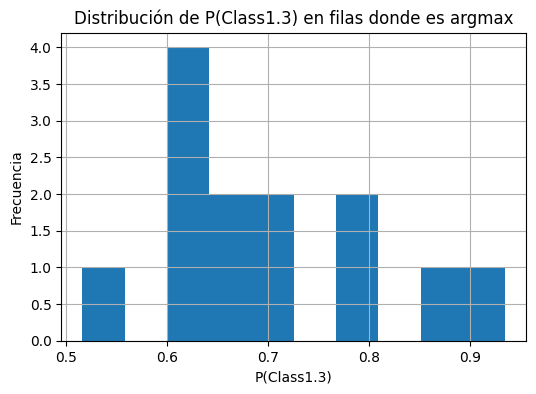

In [21]:
# Inspección de las filas donde Class1.3 fue argmax
import pandas as pd
import matplotlib.pyplot as plt

cols = pd.read_csv("training_solutions_rev1.csv").drop(columns=["GalaxyID"])
argmax = cols.idxmax(axis=1)
mask = argmax == "Class1.3"
rows = cols[mask]

print("Número de filas donde Class1.3 es argmax:", len(rows))
print("\nEstadísticas de la columna Class1.3 en esas filas:")
print(rows["Class1.3"].describe())

# ¿Cuántas tienen probabilidad > 0.5 / > 0.33 / > 0.2?
for thr in (0.5, 0.33, 0.2, 0.1):
    print(f"Prob > {thr}: {(rows['Class1.3'] > thr).sum()}")

# Distribución de la probabilidad máxima en esas filas (debería ser igual a Class1.3 porque es argmax)
max_vals = rows.max(axis=1)
print("\nEstadísticas de la probabilidad máxima en esas filas:")
print(max_vals.describe())

# Mostrar top-3 probabilidades por cada una de las filas (útil para ver cuán competitiva es la máxima)
def topk(row, k=3):
    return row.sort_values(ascending=False).head(k)

for i, (idx, row) in enumerate(rows.iterrows()):
    print(f"\nFila {i} (index {idx}) - Class1.3={row['Class1.3']:.3f} - top3: {topk(row).to_dict()}")

# Histograma de las probabilidades de Class1.3 en esas filas
plt.figure(figsize=(6,4))
rows["Class1.3"].hist(bins=10)
plt.title("Distribución de P(Class1.3) en filas donde es argmax")
plt.xlabel("P(Class1.3)")
plt.ylabel("Frecuencia")
plt.show()

Aquí están las 13 fotos con su respectiva probabilidad. De esperar que todas superen el 50%

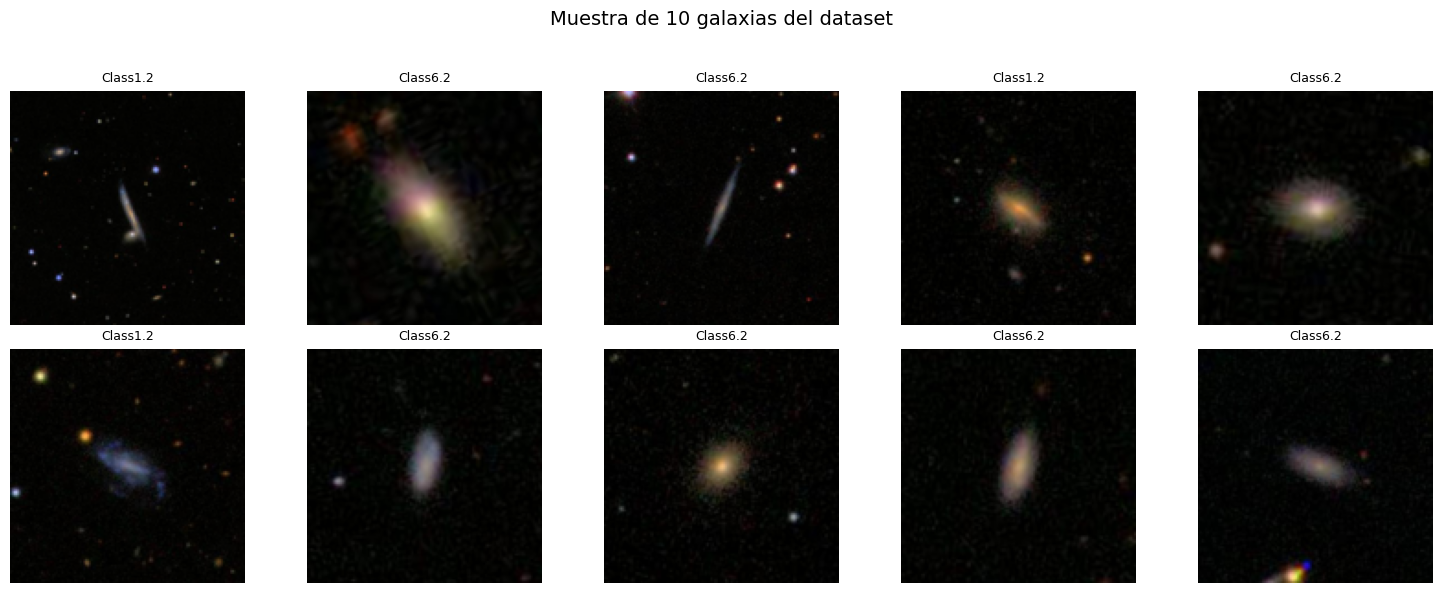

Clases: ['Class6.2', 'Class1.1', 'Class6.1', 'Class1.2', 'Class1.3']
Conteos: [36706, 5449, 3470, 15940, 13]


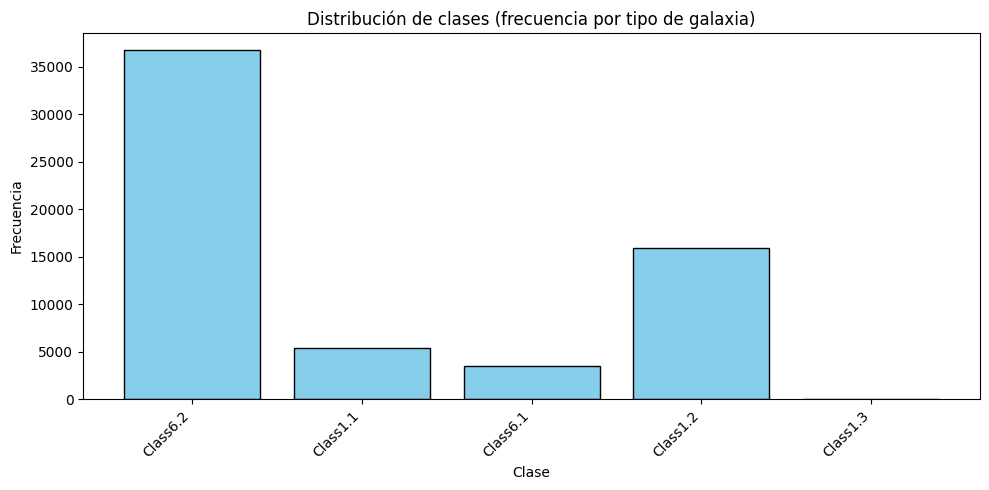

In [22]:
# ---------------------------------------------------------
# Vista previa de 10 galaxias aleatorias
# ---------------------------------------------------------
n_muestras = min(10, len(X))
indices = np.random.choice(len(X), n_muestras, replace=False)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[idx], cmap="gray")
    plt.title(y[idx], fontsize=9)
    plt.axis("off")
plt.suptitle("Muestra de 10 galaxias del dataset", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ---------------------------------------------------------

frecuencias = Counter(y)
clases = list(frecuencias.keys())
conteos = list(frecuencias.values())

# Crear tabla con clases y conteos
tabla_frecuencias = pd.DataFrame({
    "Clase": clases,
    "Frecuencia": conteos
}).sort_values("Frecuencia", ascending=False).reset_index(drop=True)

# ---------------------------------------------------------
# Distribución de frecuencias por clase
# ---------------------------------------------------------

frecuencias = Counter(y)
clases = list(frecuencias.keys())
conteos = list(frecuencias.values())

print("Clases:", clases)
print("Conteos:", conteos)

plt.figure(figsize=(10, 5))
plt.bar(clases, conteos, color="skyblue", edgecolor="black")
plt.title("Distribución de clases (frecuencia por tipo de galaxia)")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



# Entrenamiento de los modelos


### Preparación de datos

In [25]:

X_r_rgb = np.array([img.flatten() for img in X])
print(f"Forma de las características RGB aplanadas: {X_r_rgb.shape}")

# 1.2. CONJUNTO GRAYSCALE: Convertir a grises, luego aplanar
X_r_gray = []
for img in X:
    # img[:,:,0] es el canal R, img[:,:,1] es G, img[:,:,2] es B
    img_gray = (0.2989 * img[:,:,0] + 
                0.5870 * img[:,:,1] + 
                0.1140 * img[:,:,2])
    
    # Aplanar el array de Grayscale (que ahora es (128, 128))
    X_r_gray.append(img_gray.flatten())

X_r_gray = np.array(X_r_gray)
print(f"Forma de las características Grayscale aplanadas: {X_r_gray.shape}")

# El resto del código se mantiene sin cambios
# -------------------------------------------
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("\nCodificación de Etiquetas:")
print("Ejemplo etiquetas codificadas:", y[:5], "->", y_enc[:5])

# --- CONJUNTO RGB: División de X_r_rgb ---
X_rgb_train, X_rgb_test, y_train, y_test = train_test_split(
    X_r_rgb, y_enc, test_size=0.3, random_state=40
)

# --- CONJUNTO GRAYSCALE: División de X_r_gray ---
X_gray_train, X_gray_test, _, _ = train_test_split(
    X_r_gray, y_enc, test_size=0.3, random_state=40
)

print("\n--- División de Datos ---")
print("Tamaño Train RGB:", X_rgb_train.shape, " | Tamaño Test RGB:", X_rgb_test.shape)
print("Tamaño Train Gray:", X_gray_train.shape, " | Tamaño Test Gray:", X_gray_test.shape)
print("Tamaño Etiquetas Train:", y_train.shape, " | Tamaño Etiquetas Test:", y_test.shape)

# --- ESCALADO RGB ---
scaler_rgb = StandardScaler()
X_train_s_rgb = scaler_rgb.fit_transform(X_rgb_train)
X_test_s_rgb = scaler_rgb.transform(X_rgb_test)
print("\nEscalado RGB completado.")

# --- ESCALADO GRAYSCALE ---
scaler_gray = StandardScaler()
X_train_s_gray = scaler_gray.fit_transform(X_gray_train)
X_test_s_gray = scaler_gray.transform(X_gray_test)
print("Escalado Grayscale completado.")

MemoryError: Unable to allocate 48.0 KiB for an array with shape (49152,) and data type uint8

### 1. Regresion Logistica

In [ ]:

# Parámetros fijos según tu mejor resultado
N_COMP_FIJO = 1000 
C_FIJO = 0.0003 

# Configuramos el modelo de Regresión Logística con los parámetros fijos
logreg_final = LogisticRegression(
    C=C_FIJO,
    max_iter=10000, 
    solver='lbfgs', 
    random_state=40,
    class_weight='balanced'
)

final_results_rgb = None
data_key = 'rgb'

print(f"--- INICIANDO EVALUACIÓN FINAL: REGRESIÓN LOGÍSTICA RGB (PCA={N_COMP_FIJO}, C={C_FIJO}) ---")

# =================================================================
# 2. ENTRENAMIENTO Y EVALUACIÓN (SOLO RGB)
# =================================================================

# 2.1. Configuración de datos de entrenamiento/prueba (SOLO RGB)
data_train = X_train_s_rgb
data_test = X_test_s_rgb

# 2.2. Recuperar/Calcular PCA = 1000
try:
    # Asumimos que pca_cache[data_key][N_COMP_FIJO] existe
    X_train_pca = pca_cache[data_key][N_COMP_FIJO]['X_train']
    X_test_pca = pca_cache[data_key][N_COMP_FIJO]['X_test'] 
except (KeyError, NameError):
    print(f"ERROR: No se encontró PCA={N_COMP_FIJO} en caché. Recalculando PCA...")
    
    # Fallback de Recálculo
    pca = PCA(n_components=N_COMP_FIJO, random_state=40)
    X_train_pca = pca.fit_transform(data_train)
    X_test_pca = pca.transform(data_test)
    
    # Asegurar que se guarda en el caché si existe
    if 'pca_cache' in globals() and N_COMP_FIJO not in pca_cache[data_key]:
         pca_cache[data_key][N_COMP_FIJO] = {'X_train': X_train_pca, 'X_test': X_test_pca}
        
start_time = time.time()

# 2.3. Entrenar el modelo
modelo_entrenado = logreg_final.fit(X_train_pca, y_train)

end_time = time.time()

# 2.4. Evaluar en el conjunto de prueba
y_pred = modelo_entrenado.predict(X_test_pca)
report = classification_report(y_test, y_pred, output_dict=True, zero_division=1) 

final_results_rgb = {
    'n_comp': N_COMP_FIJO,
    'C_optimo': C_FIJO,
    'model': modelo_entrenado,
    'f1': report['macro avg']['f1-score'],
    'acc': report['accuracy'],
    'precision': report['weighted avg']['precision'],
    'recall': report['weighted avg']['recall'],
    'time': end_time - start_time
}

print(f"\n  ✅ Entrenamiento y Evaluación completados en {final_results_rgb['time']:.2f} segundos.")
    
# =================================================================
# 3. REPORTE FINAL: SOLO RGB
# =================================================================

print("\n\n" + "="*80)
print(f"  🏆 REPORTE FINAL: REGRESIÓN LOGÍSTICA RGB (PCA={N_COMP_FIJO}, C={C_FIJO}) 🏆")
print("================================================================================\n")

res = final_results_rgb
if res:
    print(f"[ CONFIGURACIÓN FINAL: RGB ]")
    print(f"  PCA Fijo:                  {res['n_comp']}")
    print(f"  C Óptimo (Fijo):           {res['C_optimo']:.4f}")
    print(f"  Balanceo de Clases:        Activado")
    print("-" * 35)
    print(f"  Precisión (Accuracy):      {res['acc']:.4f}")
    print(f"  F1-Macro:                  {res['f1']:.4f}")
    print(f"  Precision (Weighted):      {res['precision']:.4f}")
    print(f"  Recall (Weighted):         {res['recall']:.4f}")
else:
    print("No se pudo obtener el resultado final para RGB.")
    
print("\n" + "="*80)

--- INICIANDO EVALUACIÓN FINAL: REGRESIÓN LOGÍSTICA RGB (PCA=1000, C=0.0003) ---

  ✅ Entrenamiento y Evaluación completados en 45.51 segundos.


  🏆 REPORTE FINAL: REGRESIÓN LOGÍSTICA RGB (PCA=1000, C=0.0003) 🏆

[ CONFIGURACIÓN FINAL: RGB ]
  PCA Fijo:                  1000
  C Óptimo (Fijo):           0.0003
  Balanceo de Clases:        Activado
-----------------------------------
  Precisión (Accuracy):      0.4514
  F1-Macro:                  0.2771
  Precision (Weighted):      0.5573
  Recall (Weighted):         0.4514




--- Generando Curvas ROC ---


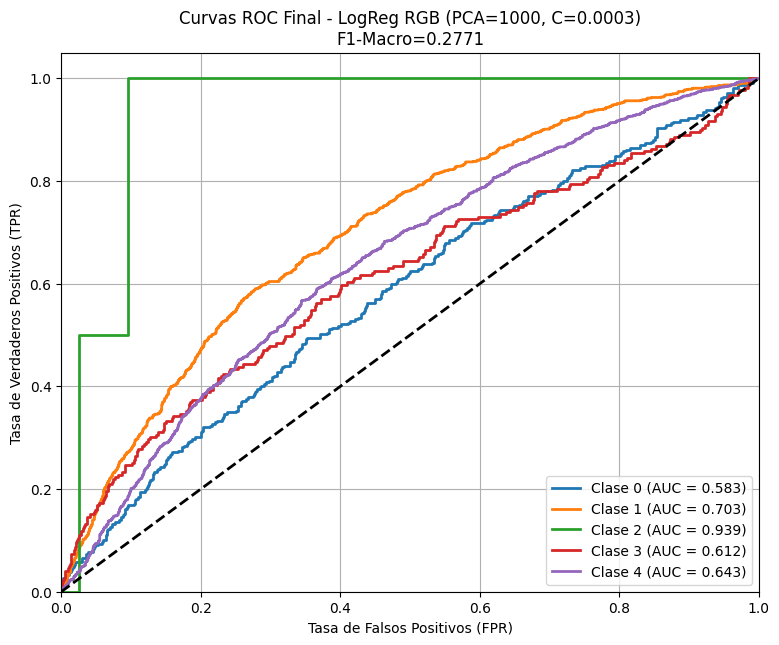

<Figure size 800x600 with 0 Axes>

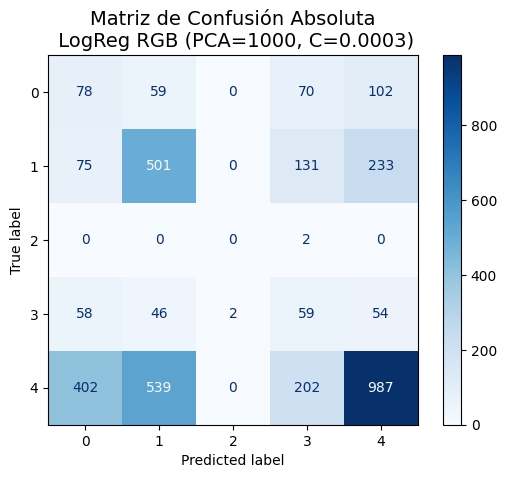

In [ ]:
modelo_final = final_results_rgb['model']
C_FIJO = final_results_rgb['C_optimo']
N_COMP_FIJO = final_results_rgb['n_comp']
data_key = 'rgb'

# 1.1. Recuperar X_test transformado (PCA=1000)
try:
    X_test_pca = pca_cache[data_key][N_COMP_FIJO]['X_test']
except (KeyError, NameError):
    print("Error: Los datos PCA no están en caché. Saliendo de la graficación.")
    exit()

# 1.2. Obtener clases, probabilidades y predicciones
clases = modelo_final.classes_
y_test_bin = label_binarize(y_test, classes=clases)
y_score = modelo_final.predict_proba(X_test_pca)
y_pred = modelo_final.predict(X_test_pca) 
n_clases = len(clases)


# =================================================================
# 2. GRÁFICA 1: CURVAS ROC (One-vs-Rest)
# =================================================================

print("\n--- Generando Curvas ROC ---")

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_clases):
    if y_test_bin.shape[1] > i:
         try:
             # Se asegura que la clase tenga al menos dos valores distintos para el cálculo
             if len(np.unique(y_test_bin[:, i])) > 1:
                 fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
                 roc_auc[i] = auc(fpr[i], tpr[i])
             else:
                 print(f"  > Clase {clases[i]} excluida de ROC por insuficiencia de valores binarios.")
                 continue
         except ValueError:
             print(f"  > Clase {clases[i]} excluida de ROC por error en cálculo.")
             continue
    else:
         continue 

plt.figure(figsize=(9, 7))

for i in range(n_clases):
    if i in roc_auc:
        plt.plot(fpr[i], tpr[i], lw=2, 
                 label=f'Clase {clases[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')

f1_final = final_results_rgb['f1']
plt.title(f'Curvas ROC Final - LogReg RGB (PCA={N_COMP_FIJO}, C={C_FIJO:.4f})\nF1-Macro={f1_final:.4f}', fontsize=12)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 3.1. Calcular la matriz (Conteo Absoluto)
cm = confusion_matrix(y_test, y_pred, labels=clases)

# 3.2. Configurar el gráfico usando ConfusionMatrixDisplay
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap=plt.cm.Blues, values_format='d') # 'd' para mostrar conteos enteros

plt.title(f'Matriz de Confusión Absoluta\n LogReg RGB (PCA={N_COMP_FIJO}, C={C_FIJO:.4f})', fontsize=14)
# ConfusionMatrixDisplay maneja las etiquetas de eje X/Y automáticamente
plt.grid(False) 
plt.show()

### 2. Arbol de desicion

In [ ]:
if 'pca_cache' not in globals():
    pca_cache = {
        'rgb': {},
        'gray': {}
    }

# =================================================================
# 1. PARÁMETROS FINALES FIJOS
# =================================================================

DATA_KEY = 'rgb'
N_COMP_FIJO = 1000 
CRITERION_FIJO = 'entropy'
MAX_DEPTH_FIJO = 20    # Fijo según tu elección
MIN_SAMPLES_LEAF_FIJO = 20 # Fijo según tu elección
RANDOM_STATE_FIJO = 40

print(f"--- INICIANDO ENTRENAMIENTO FINAL ({DATA_KEY.upper()}) ---")
print(f"PCA={N_COMP_FIJO}, Criterio='{CRITERION_FIJO}', Depth={MAX_DEPTH_FIJO}, Leaf={MIN_SAMPLES_LEAF_FIJO}")

# =================================================================
# 2. CONFIGURACIÓN Y PREPARACIÓN DE DATOS
# =================================================================

# 2.1. Configuración de datos de entrenamiento/prueba (SOLO RGB)
# Asumiendo que X_train_s_rgb y X_test_s_rgb están definidos
data_train = X_train_s_rgb
data_test = X_test_s_rgb

# 2.2. Recuperar/Calcular PCA = 1000
try:
    X_train_pca = pca_cache[DATA_KEY][N_COMP_FIJO]['X_train']
    X_test_pca = pca_cache[DATA_KEY][N_COMP_FIJO]['X_test'] 
    print(f"PCA={N_COMP_FIJO} recuperado de la caché.")
except KeyError:
    print(f"PCA={N_COMP_FIJO} no encontrado en caché. Calculando PCA...")
    
    # Crear la instancia de PCA y ajustarla a los datos de entrenamiento
    pca = PCA(n_components=N_COMP_FIJO, random_state=RANDOM_STATE_FIJO)
    X_train_pca = pca.fit_transform(data_train)
    X_test_pca = pca.transform(data_test)
    
    # Guardar en caché
    pca_cache[DATA_KEY][N_COMP_FIJO] = {'X_train': X_train_pca, 'X_test': X_test_pca}
    print(f"PCA={N_COMP_FIJO} calculado y almacenado en caché.")


# =================================================================
# 3. ENTRENAMIENTO Y MEDICIÓN DEL TIEMPO
# =================================================================

arbol_final = DecisionTreeClassifier(
    criterion=CRITERION_FIJO, 
    max_depth=MAX_DEPTH_FIJO,
    min_samples_leaf=MIN_SAMPLES_LEAF_FIJO,
    random_state=RANDOM_STATE_FIJO
)

print("\n--- Iniciando Entrenamiento ---")
start_time = time.time()

# Entrenar el modelo
# Se asume que 'y_train' está definido.
arbol_final.fit(X_train_pca, y_train)

end_time = time.time()
training_time = end_time - start_time

print(f"--- Entrenamiento Completado en {training_time:.2f} segundos ---")


# =================================================================
# 4. EVALUACIÓN Y REPORTE FINAL
# =================================================================

# Predicciones
# Se asume que 'y_test' está definido.
y_pred = arbol_final.predict(X_test_pca)

# Reporte de clasificación
report = classification_report(y_test, y_pred, output_dict=True, zero_division=1) 
 
# Resultados finales
final_results = {
    'training_time': training_time,
    'n_comp': N_COMP_FIJO,
    'criterion': CRITERION_FIJO,
    'max_depth': MAX_DEPTH_FIJO,
    'min_samples_leaf': MIN_SAMPLES_LEAF_FIJO,
    'acc': report['accuracy'],
    'f1': report['macro avg']['f1-score'],
    'precision': report['weighted avg']['precision'],
    'recall': report['weighted avg']['recall']
}


print("\n\n" + "="*80)
print(" 🏆 RESULTADO FINAL DEL MODELO ESPECÍFICO (RGB) 🏆")
print("================================================================================\n")
print(f"  [ MODELO FINAL: RGB ]")
print(f"  PCA Fijo:                  {final_results['n_comp']}")
print(f"  Criterio Fijo:             {final_results['criterion']}")
print(f"  Max_Depth Fija:            {final_results['max_depth']}")
print(f"  Min_Samples_Leaf Fijo:     {final_results['min_samples_leaf']}")
print("-" * 35)
print(f"  Tiempo de Entrenamiento:   {final_results['training_time']:.2f} segundos")
print("-" * 35)
print(f"  Precisión (Accuracy):      {final_results['acc']:.4f}")
print(f"  F1-Macro:                  {final_results['f1']:.4f}")
print(f"  Precision (Weighted):      {final_results['precision']:.4f}")
print(f"  Recall (Weighted):         {final_results['recall']:.4f}")
print("\n" + "="*80)


--- INICIANDO ENTRENAMIENTO FINAL (RGB) ---
PCA=1000, Criterio='entropy', Depth=20, Leaf=20
PCA=1000 no encontrado en caché. Calculando PCA...
PCA=1000 calculado y almacenado en caché.

--- Iniciando Entrenamiento ---
--- Entrenamiento Completado en 14.70 segundos ---


 🏆 RESULTADO FINAL DEL MODELO ESPECÍFICO (RGB) 🏆

  [ MODELO FINAL: RGB ]
  PCA Fijo:                  1000
  Criterio Fijo:             entropy
  Max_Depth Fija:            20
  Min_Samples_Leaf Fijo:     20
-----------------------------------
  Tiempo de Entrenamiento:   14.70 segundos
-----------------------------------
  Precisión (Accuracy):      0.5189
  F1-Macro:                  0.2428
  Precision (Weighted):      0.4827
  Recall (Weighted):         0.5189



--- Generando ROC y Matriz de Confusión para el Modelo RGB Final ---


<Figure size 800x600 with 0 Axes>

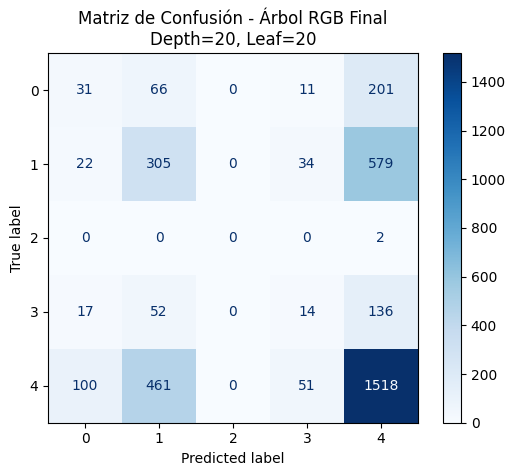

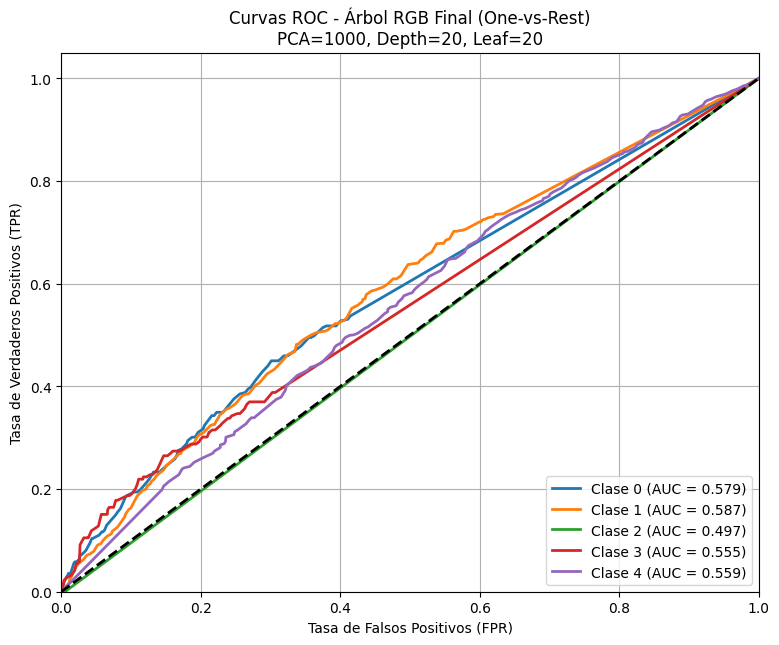

In [ ]:

print(f"--- Generando ROC y Matriz de Confusión para el Modelo RGB Final ---")


# =================================================================
# 1. MATRIZ DE CONFUSIÓN
# =================================================================

y_pred = arbol_final.predict(X_test_pca)
cm = confusion_matrix(y_test, y_pred, labels=clases)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f'Matriz de Confusión - Árbol {DATA_KEY.upper()} \nDepth={MAX_DEPTH_FIJO}, Leaf={MIN_SAMPLES_LEAF_FIJO}')
plt.grid(False) # Desactivar la cuadrícula para las matrices de confusión
plt.show()


# =================================================================
# 2. CURVAS ROC (ONE-VS-REST)
# =================================================================

# Binarizar las etiquetas de prueba (y_test) para el cálculo de ROC multiclas
y_test_bin = label_binarize(y_test, classes=clases)

# Obtener las puntuaciones de probabilidad (y_score)
y_score = arbol_final.predict_proba(X_test_pca)

# Calcular la curva ROC y el AUC para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_clases):
    if y_test_bin.shape[1] > i:
         try:
             # Solo calculamos si la clase tiene variabilidad
             if len(np.unique(y_test_bin[:, i])) > 1:
                 fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
                 roc_auc[i] = auc(fpr[i], tpr[i])
             else:
                 print(f"  > Clase {clases[i]} excluida de ROC por insuficiencia de valores binarios.")
                 continue
         except ValueError:
             print(f"  > Clase {clases[i]} excluida de ROC por error en cálculo.")
             continue
    else:
         continue 

# Graficar la Curva ROC
plt.figure(figsize=(9, 7))

for i in range(n_clases):
    if i in roc_auc:
        plt.plot(fpr[i], tpr[i], lw=2, 
                 label=f'Clase {clases[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title(f'Curvas ROC - Árbol {DATA_KEY.upper()} Final (One-vs-Rest)\nPCA={N_COMP_FIJO}, Depth={MAX_DEPTH_FIJO}, Leaf={MIN_SAMPLES_LEAF_FIJO}', fontsize=12)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
